# NHANES Diabetes Execution — 01

Treinamento sem fasting glucose, usando o dataset feminino completo. A imputação ocorre somente dentro do pipeline, depois da separação treino/teste.

## Step 01 — Carregamento e filtragem de corte

O dataset completo é carregado e são selecionadas somente features clínicas justificadas. SEQN é mantido para rastreabilidade, mas não é usado como feature.

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_recall_curve, precision_score, recall_score, roc_auc_score, roc_curve
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore', category=UserWarning, module='shap')
random_state = 42
data_dir = Path('../data/processed/nhanes')
raw_data = pd.read_csv(data_dir / 'seqn_unique_female.csv', encoding='utf-8-sig', low_memory=False)
sas_missing_marker = 5.397605346934028e-79
numeric_columns = raw_data.select_dtypes(include='number').columns
raw_data[numeric_columns] = raw_data[numeric_columns].replace(sas_missing_marker, float('nan'))

target_source_column = 'DIQ_L__DIQ010'
feature_columns = ['DEMO_L__RIDAGEYR', 'BMX_L__BMXWT', 'BMX_L__BMXHT', 'BMX_L__BMXBMI', 'BMX_L__BMXWAIST', 'BPXO_L__BPXOSY1', 'BPXO_L__BPXODI1', 'GHB_L__LBXGH', 'TCHOL_L__LBXTC', 'HDL_L__LBDHDD']
required_columns = ['SEQN', target_source_column] + feature_columns
missing_columns = [column for column in required_columns if column not in raw_data.columns]
if missing_columns:
    raise KeyError(f'Missing required columns: {missing_columns}')

cohort_data = raw_data[required_columns].copy()
cohort_data['target'] = cohort_data[target_source_column].map({1.0: 1, 2.0: 0})
cohort_data = cohort_data.dropna(subset=['target']).copy()
cohort_data['target'] = cohort_data['target'].astype('int8')
X = cohort_data[feature_columns].copy()
y = cohort_data['target'].copy()
print('Source shape:', raw_data.shape)
print('Cohort shape:', cohort_data.shape)
print('Target distribution:', y.value_counts().sort_index().to_dict())

D:\projects\tech-challenge-11iadt-fase-01\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Source shape: (6358, 862)
Cohort shape: (6114, 13)
Target distribution: {0: 5557, 1: 557}


## Step 02 — Remoção de identificadores e variáveis de leakage

A coluna usada para construir o target não entra em X. SEQN, pesos amostrais e variáveis de tratamento do diabetes também ficam fora das features clínicas.

In [2]:
print('X shape:', X.shape)
print('Target source in X:', target_source_column in X.columns)
print('SEQN in X:', 'SEQN' in X.columns)
print('Missing values before pipeline:', int(X.isna().sum().sum()))

X shape: (6114, 10)
Target source in X: False
SEQN in X: False
Missing values before pipeline: 18836


## Step 03 — Separação estratificada de treino e teste

O teste é separado antes de qualquer ajuste. A estratificação preserva a proporção de casos positivos nos dois conjuntos.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=random_state, stratify=y)
print('X_train:', X_train.shape, 'X_test:', X_test.shape)
print('Train distribution:', y_train.value_counts(normalize=True).sort_index().round(4).to_dict())
print('Test distribution:', y_test.value_counts(normalize=True).sort_index().round(4).to_dict())

X_train: (4891, 10) X_test: (1223, 10)
Train distribution: {0: 0.9088, 1: 0.0912}
Test distribution: {0: 0.9092, 1: 0.0908}


## Step 04 — Pipeline de valores faltantes

A mediana é calculada somente no conjunto usado para ajuste. O indicador de missing preserva a informação de que uma medida estava ausente. O scaler é necessário para Logistic Regression e é mantido no pipeline para reproduzir exatamente a mesma transformação no teste.

In [4]:
def create_preprocessor():
    numeric_preprocessor = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median', add_indicator=True)),
        ('scaler', StandardScaler())
    ])
    return ColumnTransformer(
        transformers=[('numeric', numeric_preprocessor, feature_columns)],
        remainder='drop'
    )

print('Preprocessing factory created.')

Preprocessing factory created.


## Step 05 — Definição dos algoritmos

Logistic Regression fornece uma referência linear. Random Forest captura relações não lineares. O balanceamento de classes aumenta a atenção dos modelos à classe diabetes, que é minoritária.

In [5]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, class_weight='balanced', random_state=random_state),
    'Random Forest': RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=random_state, n_jobs=-1)
}
model_pipelines = {
    name: Pipeline(steps=[('preprocessing', create_preprocessor()), ('model', model)])
    for name, model in models.items()
}
print('Models:', list(model_pipelines))

Models: ['Logistic Regression', 'Random Forest']


## Step 06 — Validação cruzada no treino

A validação cruzada estima a estabilidade dos modelos usando somente X_train e y_train. O conjunto de teste permanece reservado para a avaliação final.

In [6]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)
scoring = {'accuracy': 'accuracy', 'recall': 'recall', 'f1': 'f1'}
cv_rows = []
for name, pipeline in model_pipelines.items():
    result = cross_validate(pipeline, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    cv_rows.append({'model': name, 'accuracy': result['test_accuracy'].mean(), 'recall': result['test_recall'].mean(), 'f1': result['test_f1'].mean()})
cv_results = pd.DataFrame(cv_rows).set_index('model').round(4)
print(cv_results.to_string())

                     accuracy  recall      f1
model                                        
Logistic Regression    0.8436  0.8542  0.4989
Random Forest          0.8847  0.7040  0.5291


## Step 07 — Treinamento

Cada pipeline é ajustado exclusivamente com os dados de treino. Isso inclui imputação, padronização e treinamento do algoritmo.

In [7]:
fitted_models = {}
for name, pipeline in model_pipelines.items():
    pipeline.fit(X_train, y_train)
    fitted_models[name] = pipeline
    print(f'{name}: training completed')

Logistic Regression: training completed
Random Forest: training completed


## Step 08 — Teste e geração de probabilidades

As predições são feitas no conjunto de teste, que não participou do ajuste. As probabilidades permitem analisar diferentes thresholds além do padrão 0,50.

In [8]:
test_predictions = {name: pipeline.predict(X_test) for name, pipeline in fitted_models.items()}
test_probabilities = {name: pipeline.predict_proba(X_test)[:, 1] for name, pipeline in fitted_models.items()}
print('Test predictions completed.')

Test predictions completed.


## Step 09 — Avaliação com métricas médicas

Accuracy mede acertos gerais. Recall mede a proporção de casos de diabetes encontrados, sendo importante para reduzir falsos negativos. F1-Score equilibra precision e recall; ROC-AUC mede a ordenação das probabilidades.

In [9]:
metric_rows = []
for name in fitted_models:
    predictions = test_predictions[name]
    probabilities = test_probabilities[name]
    metric_rows.append({'model': name, 'accuracy': accuracy_score(y_test, predictions), 'recall': recall_score(y_test, predictions, zero_division=0), 'f1_score': f1_score(y_test, predictions, zero_division=0), 'precision': precision_score(y_test, predictions, zero_division=0), 'roc_auc': roc_auc_score(y_test, probabilities)})
test_metrics = pd.DataFrame(metric_rows).set_index('model').round(4)
print(test_metrics.to_string())
for name in fitted_models:
    print(f'\n{name}')
    print(classification_report(y_test, test_predictions[name], target_names=['No diabetes', 'Diabetes'], zero_division=0))

                     accuracy  recall  f1_score  precision  roc_auc
model                                                              
Logistic Regression    0.8365  0.8739    0.4924     0.3428   0.9301
Random Forest          0.8863  0.7117    0.5320     0.4247   0.9154

Logistic Regression
              precision    recall  f1-score   support

 No diabetes       0.99      0.83      0.90      1112
    Diabetes       0.34      0.87      0.49       111

    accuracy                           0.84      1223
   macro avg       0.66      0.85      0.70      1223
weighted avg       0.93      0.84      0.87      1223


Random Forest
              precision    recall  f1-score   support

 No diabetes       0.97      0.90      0.94      1112
    Diabetes       0.42      0.71      0.53       111

    accuracy                           0.89      1223
   macro avg       0.70      0.81      0.73      1223
weighted avg       0.92      0.89      0.90      1223



## Step 10 — Matrizes de confusão

A matriz mostra verdadeiros positivos, verdadeiros negativos, falsos positivos e falsos negativos. Para triagem, falsos negativos merecem atenção especial porque representam casos não identificados.

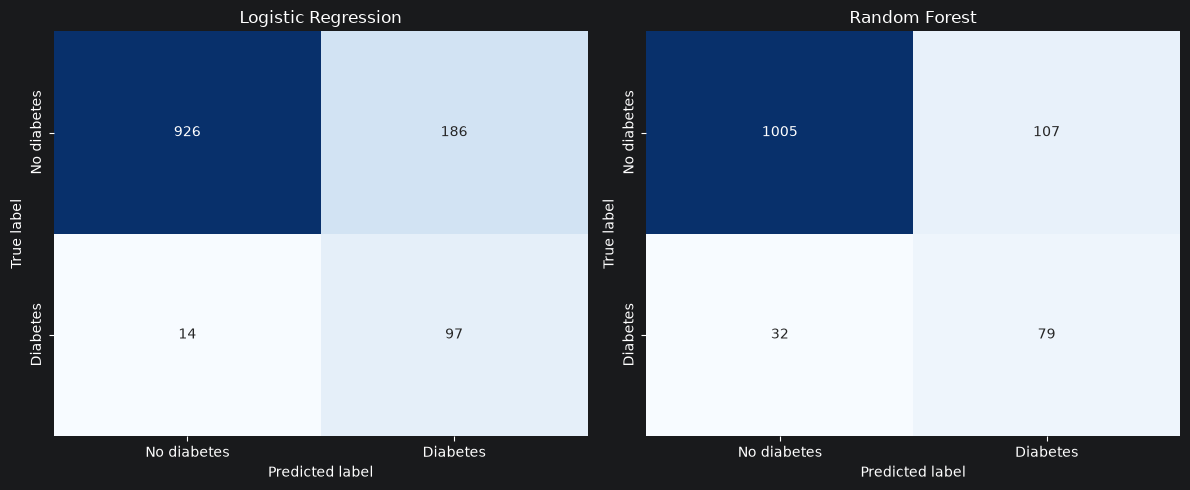

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for axis, (name, predictions) in zip(axes, test_predictions.items()):
    matrix = confusion_matrix(y_test, predictions)
    sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axis)
    axis.set_title(name)
    axis.set_xlabel('Predicted label')
    axis.set_ylabel('True label')
    axis.set_xticklabels(['No diabetes', 'Diabetes'])
    axis.set_yticklabels(['No diabetes', 'Diabetes'])
plt.tight_layout()
plt.show()

## Step 11 — Curvas ROC e Precision-Recall

ROC mostra a separação entre as classes em vários thresholds. Precision-Recall é mais informativa quando diabetes é uma classe minoritária e ajuda a avaliar o compromisso entre encontrar casos e gerar alertas falsos.

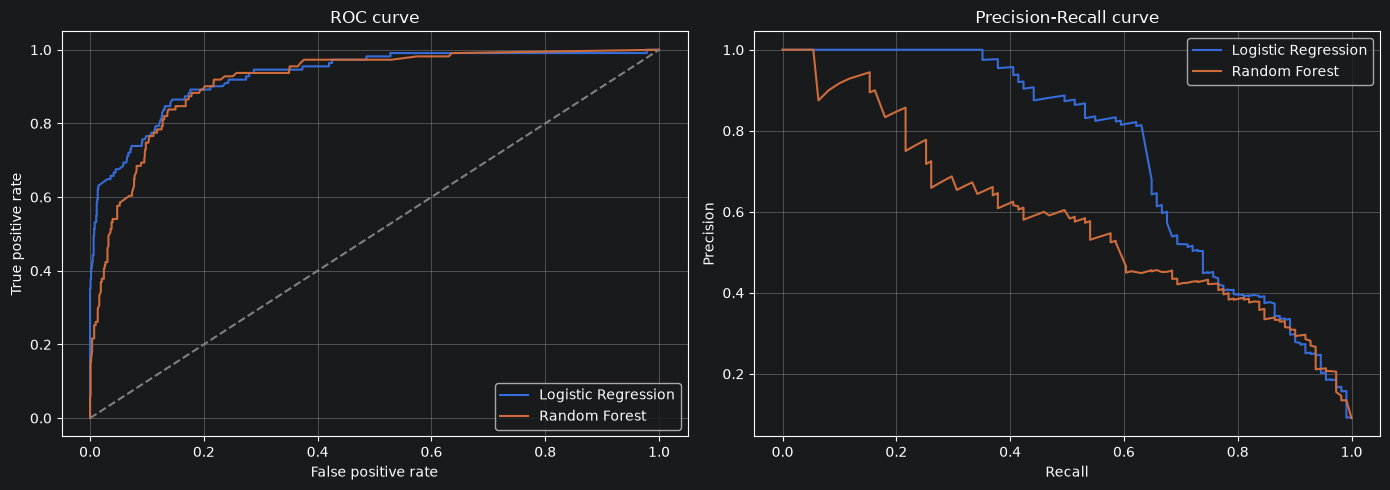

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, probabilities in test_probabilities.items():
    false_positive_rate, true_positive_rate, _ = roc_curve(y_test, probabilities)
    axes[0].plot(false_positive_rate, true_positive_rate, label=name)
    precision_values, recall_values, _ = precision_recall_curve(y_test, probabilities)
    axes[1].plot(recall_values, precision_values, label=name)
axes[0].plot([0, 1], [0, 1], '--', color='gray')
axes[0].set_title('ROC curve')
axes[0].set_xlabel('False positive rate')
axes[0].set_ylabel('True positive rate')
axes[1].set_title('Precision-Recall curve')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
for axis in axes: axis.legend(); axis.grid(True)
plt.tight_layout()
plt.show()

## Step 12 — Feature Importance do Random Forest

A importância mostra quais features contribuíram mais para as divisões das árvores. Ela descreve o comportamento do modelo, não uma relação causal ou uma evidência médica.

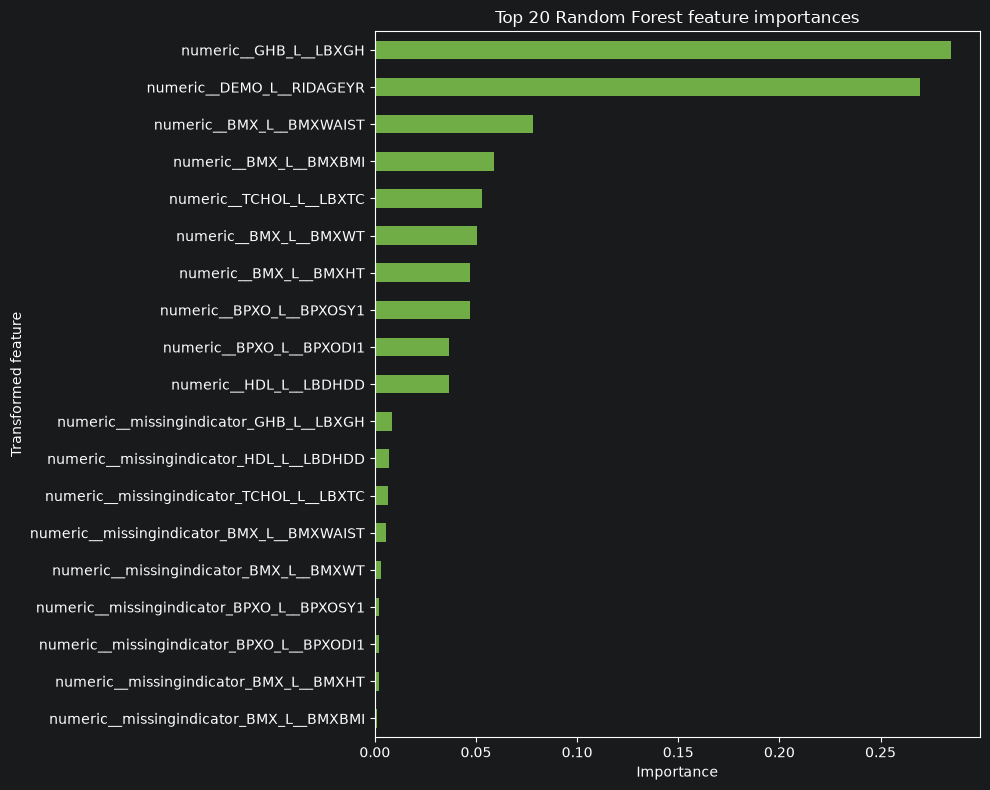

In [12]:
random_forest_pipeline = fitted_models['Random Forest']
fitted_preprocessor = random_forest_pipeline.named_steps['preprocessing']
fitted_random_forest = random_forest_pipeline.named_steps['model']
feature_names = fitted_preprocessor.get_feature_names_out()
feature_importance = pd.Series(fitted_random_forest.feature_importances_, index=feature_names).sort_values(ascending=False).head(20).sort_values()
plt.figure(figsize=(10, 8))
feature_importance.plot(kind='barh', color='#70AD47')
plt.xlabel('Importance')
plt.ylabel('Transformed feature')
plt.title('Top 20 Random Forest feature importances')
plt.tight_layout()
plt.show()

## Step 13 — Explicabilidade com SHAP

SHAP mostra como cada feature desloca a previsão do Random Forest para diabetes ou não diabetes. A explicação é específica do modelo e não substitui validação clínica.

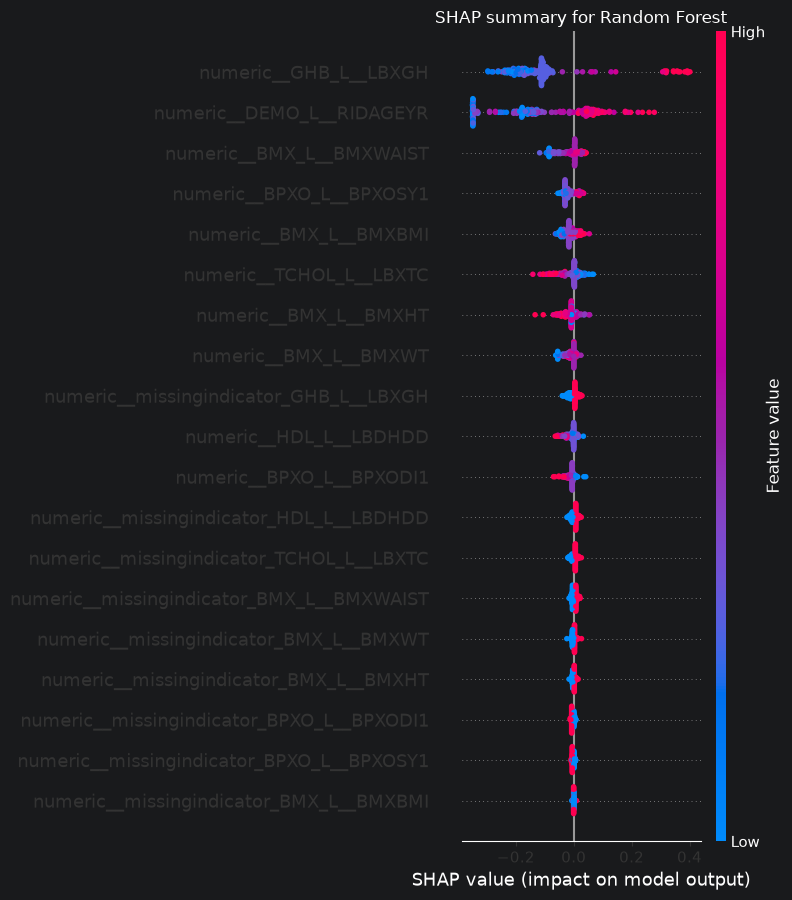

In [13]:
X_shap = X_test.sample(min(200, len(X_test)), random_state=random_state)
X_shap_transformed = fitted_preprocessor.transform(X_shap)
shap_explainer = shap.TreeExplainer(fitted_random_forest)
shap_values = shap_explainer.shap_values(X_shap_transformed)
if isinstance(shap_values, list): shap_positive_class = shap_values[1]
elif getattr(shap_values, 'ndim', 0) == 3: shap_positive_class = shap_values[:, :, 1]
else: shap_positive_class = shap_values
shap.summary_plot(shap_positive_class, X_shap_transformed, feature_names=feature_names, show=False)
plt.title('SHAP summary for Random Forest')
plt.tight_layout()
plt.show()

## Step 14 — Checklist metodológico

Antes de usar os resultados no relatório, deve-se discutir o target autorreferido, o desbalanceamento, a possibilidade de leakage pela HbA1c, a definição de população adulta e os pesos amostrais do NHANES.

In [14]:
print('Target source excluded from X:', target_source_column not in X.columns)
print('SEQN excluded from X:', 'SEQN' not in X.columns)
print('Imputation inside pipeline: True')
print('Test set used after training: True')
print('Models evaluated:', list(fitted_models))

Target source excluded from X: True
SEQN excluded from X: True
Imputation inside pipeline: True
Test set used after training: True
Models evaluated: ['Logistic Regression', 'Random Forest']
